Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 200 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Epoch 1/5
7/7 [==============================] - 66s 9s/step - loss: 0.8443 - accuracy: 0.5400 - val_loss: 0.6888 - val_accuracy: 0.8000
Epoch 2/5
7/7 [==============================] - 65s 9s/step - loss: 0.6719 - accuracy: 0.5450 - val_loss: 0.6225 - val_accuracy: 0.7167
Epoch 3/5
7/7 [==============================] - 67s 9s/step - loss: 0.6140 - accuracy: 0.6750 - val_loss: 0.6319 - val_accuracy: 0.6333
Epoch 4/5
7/7 [==============================] - 61s 8s/step - loss: 0.6176 - accuracy: 0.6650 - val_loss: 0.5609 - val_accuracy: 0.7000
Epoch 5/5
2/2 [==============================] - 4s 2s/step - loss: 0.5518 - accuracy: 0.7000
Validation Accuracy: 0.699999988079071
2/2 [==============================] - 4s 2s/step
Classification Report:
               precision    recall  

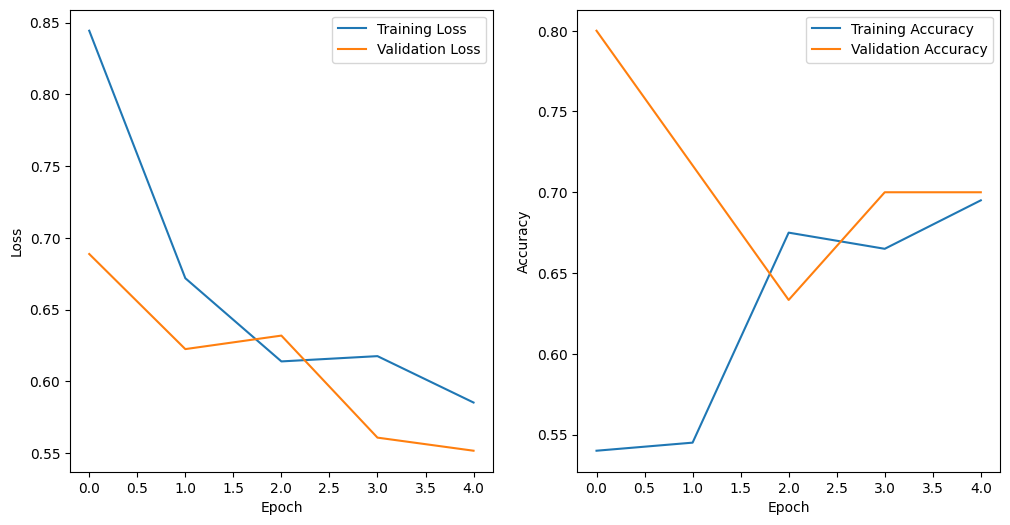

1/1 [==============================] - 0s 138ms/step


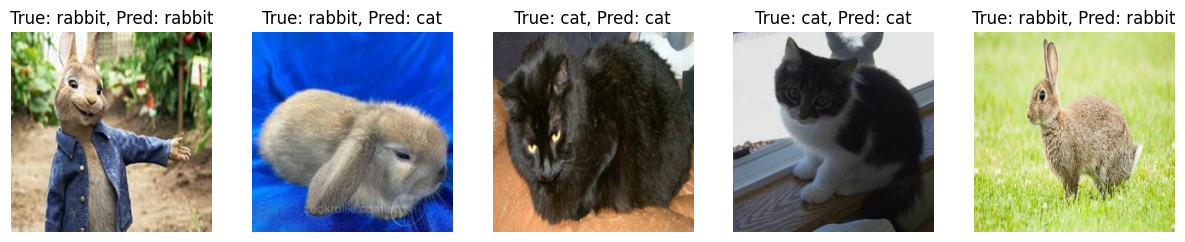

In [23]:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random


# Montage du Google Drive pour accéder à la base de données
from google.colab import drive
drive.mount('/content/drive')

# Chemin vers la base de données
train_path = '/content/drive/My Drive/Dataset 1/Dataset 1/train-cat-rabbit'
val_path = '/content/drive/My Drive/Dataset 1/Dataset 1/val-cat-rabbit'


# Définition des paramètres
batch_size = 32
input_shape = (300, 300, 3)
num_classes = 2

# Création des générateurs d'images avec augmentation des données
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(input_shape[0], input_shape[1]),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(input_shape[0], input_shape[1]),
    batch_size=batch_size,
    class_mode='categorical'
)

# Définition du modèle CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
cnn_history = cnn_model.fit(train_generator, epochs=5, validation_data=val_generator)

# Évaluation des performances du modèle
val_scores = cnn_model.evaluate(val_generator)
print(f"Validation Accuracy: {val_scores[1]}")

# Calcul des métriques de classification
val_predictions = cnn_model.predict(val_generator)
val_class_labels = np.argmax(val_predictions, axis=1)
val_true_labels = val_generator.classes

val_report = classification_report(val_true_labels, val_class_labels, target_names=list(val_generator.class_indices.keys()))
val_cm = confusion_matrix(val_true_labels, val_class_labels)

print("Classification Report:\n", val_report)
print("Confusion Matrix:\n", val_cm)

# Affichage des courbes de loss et accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Prédiction et affichage des résultats
import matplotlib.pyplot as plt
import random

# Convertir les clés du dictionnaire en liste pour l'indexation
class_labels = list(val_generator.class_indices.keys())

# Sélectionner des images aléatoires de l'ensemble de validation
images, labels = next(val_generator)
num_images_to_show = 5
random_indices = random.sample(range(images.shape[0]), num_images_to_show)

plt.figure(figsize=(15, 15))
for i, idx in enumerate(random_indices):
    img = images[idx]
    true_label = np.argmax(labels[idx])
    predicted_label = np.argmax(cnn_model.predict(np.expand_dims(img, axis=0)))

    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_label]}, Pred: {class_labels[predicted_label]}")
    plt.axis('off')

plt.show()
